# Home assignment 1 — Edge gateway incident model

## The situation

You have taken over monitoring for an **edge-gateway fleet**: 24 instances
across 4 regions, logged in 2-hour windows. Each row is one window on one
instance, and `incident = 1` means that window breached the SLA.

Two things happened while you were away:

1. **Four deployments** went out during the first 60 days. Someone claims one
   of them "broke everything" and another "fixed it". Nobody checked.
2. **60 more days of logs** have piled up that nobody has looked at.

Your job: find out which deployments actually changed anything, build an
incident model, make it as good as you can, and then find out whether it still
works on the logs nobody looked at.

## What you are practising

This assignment deliberately mixes the two halves of the course:

* **the workflow** — hypothesis tests, train/test discipline, AUC, honest
  evaluation;
* **the implementation** — you write the statistics and the model in plain
  NumPy first, and only then check yourself against `scipy` / `sklearn`.

Wherever a task says *"implement by hand"*, that means NumPy only. You may
always use a library **afterwards** to check your answer, and several tasks
require exactly that.

## The five parts

| Part | Topic |
|---|---|
| 1 | Loading and cleaning |
| 2 | Did the deployments change anything? |
| 3 | Baseline model, by hand |
| 4 | Make it better (open-ended) |
| 5 | The logs nobody looked at |

This is practice, not an exam — nothing here is graded. Work through it in
order, since each part uses what the last one built.

## Notation

Used throughout, so the formulas in each task are readable:

| symbol | meaning |
|---|---|
| $n$ | number of rows (windows) |
| $d$ | number of features |
| $X \in \mathbb{R}^{n \times d}$ | the design matrix, $x_{ij}$ its entries |
| $y \in \{0,1\}^n$ | the target, `incident` |
| $s \in \mathbb{R}^n$ | model scores |
| $n_+,\; n_-$ | number of positives / negatives |
| $\mathbb{1}[\cdot]$ | 1 if the condition holds, 0 otherwise |

## Rules

* **Do not touch data after `2026-03-06` until Part 5.** That is the whole
  point of Part 5. Peeking invalidates it.
* Every model decision must be made on training data only.
* Where the notebook prints a `[PASS] / [FAIL]` self-check, get it to `PASS`
  before moving on.

## Part 0 — Setup

In [1]:
import itertools
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

RANDOM_SEED = 7
rng = np.random.default_rng(RANDOM_SEED)

BASE = Path.cwd()
if not (BASE / "data").exists() and (BASE / "assignment01" / "data").exists():
    BASE = BASE / "assignment01"
DATA = BASE / "data"
FIG = BASE / "figures"
FIG.mkdir(exist_ok=True)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Course palette — series 1 blue, series 2 orange, series 3 aqua, fixed order.
C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a"}
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "axis": "#c3c2b7", "surface": "#fcfcfb"}
plt.rcParams.update({
    "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
    "savefig.facecolor": INK["surface"], "axes.edgecolor": INK["axis"],
    "axes.labelcolor": INK["secondary"], "axes.titlecolor": INK["primary"],
    "axes.titlesize": 11, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": INK["grid"], "grid.linewidth": 0.8, "grid.linestyle": "-",
    "xtick.color": INK["muted"], "ytick.color": INK["muted"],
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.frameon": False,
    "legend.fontsize": 9, "lines.linewidth": 2.0, "font.size": 10,
    "figure.dpi": 110,
})


def finish(ax, title=None, xlabel=None, ylabel=None, legend=False):
    if title:
        ax.set_title(title, pad=10)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)
    if legend:
        ax.legend()
    return ax


def check(label, ok, detail=""):
    """Self-check. Prints rather than raising, so you can keep working."""
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}" + (f"   {detail}" if detail else ""))
    return bool(ok)


NUMERIC = ["cpu_util", "mem_util", "p99_latency_ms", "request_rate",
           "error_rate_pct", "queue_depth", "cache_hit_ratio", "gc_pause_ms",
           "active_connections", "disk_io_wait_ms"]
CATEGORICAL = ["region", "instance_type", "service_tier"]
TARGET = "incident"

DEV_END = pd.Timestamp("2026-03-06")          # <- do not look past this until Part 5
DEPLOYS = [pd.Timestamp("2026-01-17"), pd.Timestamp("2026-01-29"),
           pd.Timestamp("2026-02-10"), pd.Timestamp("2026-02-22")]
print("data:", DATA)

data: /home/dfbakin/Documents/data_science/assignment01/data


## Part 1 — Loading and cleaning

### Task 1.1 — Load the logs and look at them

Load `data/edge_gateway_logs.csv`, parsing `timestamp` as a datetime. Print
the shape, the column dtypes, and the first few rows.

In [2]:
# ---- Task 1.1 ---------------------------------------------------------------
logs = pd.read_csv(DATA / "edge_gateway_logs.csv", parse_dates=["timestamp"])

print(f"shape: {logs.shape}")
print(f"period: {logs.timestamp.min()}  ->  {logs.timestamp.max()}")
print(f"instances: {logs.instance_id.nunique()}   regions: {logs.region.nunique()}")
print(f"\ndtypes:\n{logs.dtypes.to_string()}")
logs.head()
# ---- /Task 1.1 --------------------------------------------------------------

shape: (34620, 17)
period: 2026-01-05 00:00:00  ->  2026-05-04 22:00:00
instances: 24   regions: 4

dtypes:
timestamp             datetime64[ns]
instance_id                   object
region                        object
instance_type                 object
service_tier                  object
cpu_util                     float64
mem_util                     float64
p99_latency_ms               float64
request_rate                 float64
error_rate_pct               float64
queue_depth                    int64
cache_hit_ratio              float64
gc_pause_ms                  float64
active_connections           float64
disk_io_wait_ms              float64
deploy_phase                  object
incident                       int64


,timestamp,instance_id,region,instance_type,service_tier,cpu_util,mem_util,p99_latency_ms,request_rate,error_rate_pct,queue_depth,cache_hit_ratio,gc_pause_ms,active_connections,disk_io_wait_ms,deploy_phase,incident
0,2026-01-05,gw-00,us-east-1,m5.large,pro,0.5080,0.3393,895.10,951.97,0.2074,8,0.8402,10.780,415.2,3.038,A,0
1,2026-01-05,gw-01,us-east-1,c5.xlarge,pro,0.4267,0.8441,219.14,488.65,0.0477,7,0.8879,115.969,327.7,4.429,A,0
2,2026-01-05,gw-02,us-east-1,r5.2xlarge,pro,0.5395,0.6639,39.15,513.82,0.4007,6,0.8960,3.566,244.2,0.677,A,0
3,2026-01-05,gw-03,us-west-2,m5.large,enterprise,0.9220,0.8318,44.92,867.75,0.1104,8,0.9114,15.137,514.3,1.177,A,0
4,2026-01-05,gw-04,us-west-2,c5.xlarge,free,0.6804,0.6654,43.19,525.37,0.0077,10,0.8860,16.193,354.5,0.791,A,0


### Task 1.2 — Find and fix the data quality problems

These logs came off a real collector, so they have real problems. There are
**three** of them. Find all three and fix them.

Hints, in ascending order of how much they give away:

* one is about rows, one is about empty cells, one is about a value that is
  *present* but impossible;
* `.duplicated()`, `.isna()`, and `.describe()` will each reveal one;
* a latency of `-1` ms has not been measured — it is a collector convention
  for "no data", and treating it as a number will quietly poison every model
  you build.

For each problem: report how many rows it affects, then fix it. Justify your
imputation choice in a comment.

In [3]:
# ---- Task 1.2 ---------------------------------------------------------------
print("BEFORE CLEANING")
print(f"  duplicate rows        : {logs.duplicated().sum():,}")
print(f"  missing cells         : {logs[NUMERIC].isna().sum().sum():,}")
print(logs[NUMERIC].isna().sum()[lambda s: s > 0].to_string())
print(f"  impossible latencies  : {(logs.p99_latency_ms < 0).sum():,} "
      f"(min = {logs.p99_latency_ms.min()})")

clean = logs.drop_duplicates().copy()

# The -1 sentinel is "not measured", not "very fast". Turn it into a proper NaN
# so it is imputed like any other missing value instead of dragging the mean of
# a latency column below zero.
clean["p99_latency_ms"] = clean["p99_latency_ms"].replace(-1.0, np.nan)

print("\nAFTER dedupe + sentinel -> NaN")
print(f"  rows                  : {len(clean):,}  (was {len(logs):,})")
print(f"  missing cells         : {clean[NUMERIC].isna().sum().sum():,}")
# ---- /Task 1.2 --------------------------------------------------------------

BEFORE CLEANING
  duplicate rows        : 60
  missing cells         : 761
cache_hit_ratio    311
gc_pause_ms        450
  impossible latencies  : 278 (min = -1.0)

AFTER dedupe + sentinel -> NaN
  rows                  : 34,560  (was 34,620)
  missing cells         : 1,036


### Task 1.3 — Split off the horizon

Split into:

* **`dev`** — everything strictly before `DEV_END` (2026-03-06). This is all
  you may use for Parts 2–4.
* **`horizon`** — everything from `DEV_END` onward. **Do not look at it until
  Part 5.**

Then impute the missing values. Careful: the imputation statistic must come
from `dev` only. Using the median of the whole file leaks the future into
your model — a small leak here, but exactly the same mistake that invalidates
real evaluations.

In [4]:
# ---- Task 1.3 ---------------------------------------------------------------
dev = clean[clean.timestamp < DEV_END].copy()
horizon = clean[clean.timestamp >= DEV_END].copy()

# Median, not mean: several of these columns are heavily right-skewed, so the
# mean sits well above the typical value.
impute_values = dev[NUMERIC].median()
dev[NUMERIC] = dev[NUMERIC].fillna(impute_values)
horizon[NUMERIC] = horizon[NUMERIC].fillna(impute_values)   # dev statistics!

print(f"dev     : {len(dev):,} rows   {dev.timestamp.min().date()} -> "
      f"{dev.timestamp.max().date()}")
print(f"horizon : {len(horizon):,} rows   {horizon.timestamp.min().date()} -> "
      f"{horizon.timestamp.max().date()}")
print(f"\nincident rate (dev): {dev[TARGET].mean():.4f}")

# ---- /Task 1.3 --------------------------------------------------------------

check("no missing values left", dev[NUMERIC].isna().sum().sum() == 0)
check("no duplicate rows left", dev.duplicated().sum() == 0)
check("no negative latencies", (dev.p99_latency_ms <= 0).sum() == 0)
check("dev and horizon do not overlap", dev.timestamp.max() < horizon.timestamp.min())

dev     : 17,280 rows   2026-01-05 -> 2026-03-05
horizon : 17,280 rows   2026-03-06 -> 2026-05-04

incident rate (dev): 0.2207
  [PASS] no missing values left
  [PASS] no duplicate rows left
  [PASS] no negative latencies
  [PASS] dev and horizon do not overlap


True

### Task 1.4 — Two sanity plots

Plot (a) the distribution of one heavily skewed feature before and after a
log transform, and (b) the incident rate by hour of day. Write one sentence
under each about what it tells you.

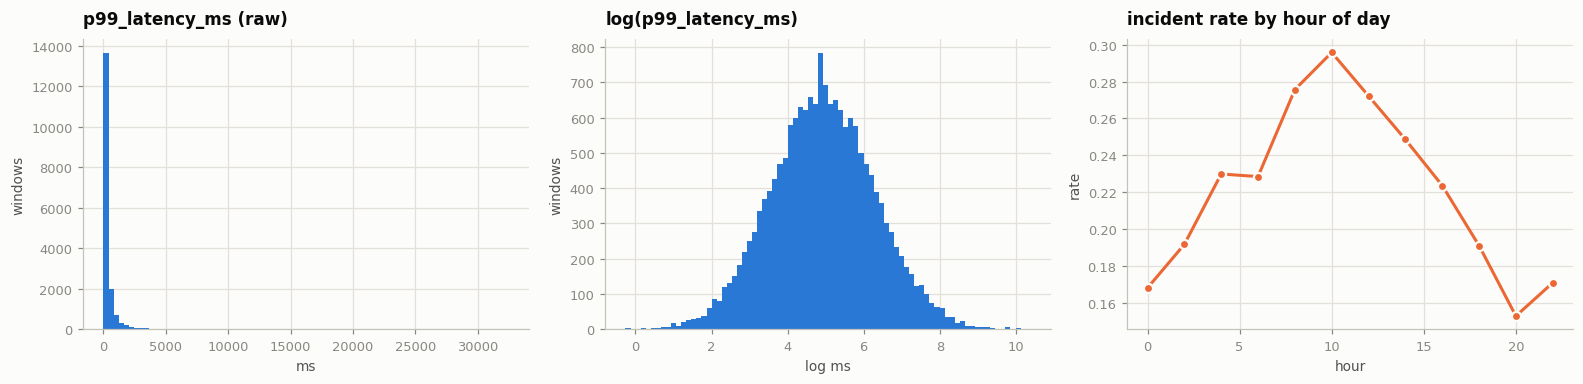

raw skew +12.74 -> log skew +0.03


In [5]:
# ---- Task 1.4 ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6))

axes[0].hist(dev.p99_latency_ms, bins=80, color=C["blue"], edgecolor="none")
finish(axes[0], "p99_latency_ms (raw)", xlabel="ms", ylabel="windows")

axes[1].hist(np.log(dev.p99_latency_ms), bins=80, color=C["blue"], edgecolor="none")
finish(axes[1], "log(p99_latency_ms)", xlabel="log ms", ylabel="windows")

hourly = dev.assign(hour=dev.timestamp.dt.hour).groupby("hour")[TARGET].mean()
axes[2].plot(hourly.index, hourly.values, "o-", color=C["orange"],
             markeredgecolor=INK["surface"], markeredgewidth=1.5)
finish(axes[2], "incident rate by hour of day", xlabel="hour", ylabel="rate")

fig.tight_layout()
fig.savefig(FIG / "01_eda.png", bbox_inches="tight", dpi=140)
plt.show()

print(f"raw skew {stats.skew(dev.p99_latency_ms):+.2f} -> "
      f"log skew {stats.skew(np.log(dev.p99_latency_ms)):+.2f}")
# ---- /Task 1.4 --------------------------------------------------------------

*(a)* Latency spans three orders of magnitude and is unusable raw; the log
turns it into a workable near-symmetric distribution.

*(b)* Incidents follow a clear daily cycle, peaking in the busy afternoon
hours. Two consequences, and they pull in opposite directions: the cycle means
**rows close together in time are not independent**, so a random train/test
split would leak (we handle that in Task 3.1) — but it does *not* automatically
make "hour of day" a useful model feature, because the thing that varies over
the day is **load**, and we already measure load directly. We come back to this
in Task 4.6.

## Part 2 — Did the deployments change anything?

Four deployments went out, splitting the development period into five phases
`A`–`E` (already labelled in `deploy_phase`):

| | date | phases compared |
|---|---|---|
| D1 | 2026-01-17 | A → B |
| D2 | 2026-01-29 | B → C |
| D3 | 2026-02-10 | C → D |
| D4 | 2026-02-22 | D → E |

### Task 2.1 — Per-phase statistics

Build a table with, for each phase: number of windows, number of incidents,
incident rate, and a 95% confidence interval for that rate.

Implement the interval **by hand**. Use the **Wilson** interval, not the
textbook normal one — the normal interval misbehaves near 0 and 1 and can
produce bounds outside `[0, 1]`.

With $x$ incidents in $n$ windows, $\hat p = x/n$, and $z$ the two-sided
normal critical value

$$z = \Phi^{-1}\!\left(1 - \tfrac{1-\text{conf}}{2}\right)
  \;=\; 1.96 \text{ for conf} = 0.95$$

the interval is centred at $c$ with half-width $h$:

$$c = \frac{\hat p + \dfrac{z^2}{2n}}{1 + \dfrac{z^2}{n}}, \qquad
  h = \frac{z\sqrt{\dfrac{\hat p(1-\hat p)}{n} + \dfrac{z^2}{4n^2}}}
           {1 + \dfrac{z^2}{n}}, \qquad
  \text{CI} = [\,c - h,\; c + h\,]$$

`stats.norm.ppf` gives you $\Phi^{-1}$. Note the interval is **not** centred
on $\hat p$ — that shift toward $1/2$ is exactly what keeps it inside
$[0,1]$.

In [6]:
# ---- Task 2.1 ---------------------------------------------------------------
def wilson_interval(x, n, conf=0.95):
    """95% Wilson score interval for a binomial proportion."""
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    p = x / n
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return centre - half, centre + half


phase_stats = []
for ph in ["A", "B", "C", "D", "E"]:
    g = dev[dev.deploy_phase == ph][TARGET]
    lo, hi = wilson_interval(g.sum(), len(g))
    phase_stats.append({"phase": ph, "windows": len(g), "incidents": int(g.sum()),
                        "rate": g.mean(), "ci_low": lo, "ci_high": hi})
phase_stats = pd.DataFrame(phase_stats)
print(phase_stats.to_string(index=False,
                            formatters={"rate": "{:.4f}".format,
                                        "ci_low": "{:.4f}".format,
                                        "ci_high": "{:.4f}".format}))

# ---- /Task 2.1 --------------------------------------------------------------

check("all five phases present", len(phase_stats) == 5)
check("intervals inside [0,1]",
      bool((phase_stats.ci_low >= 0).all() and (phase_stats.ci_high <= 1).all()))
check("every interval contains its own point estimate",
      bool(((phase_stats.ci_low <= phase_stats.rate)
            & (phase_stats.rate <= phase_stats.ci_high)).all()))

phase  windows  incidents   rate ci_low ci_high
    A     3456        688 0.1991 0.1861  0.2127
    B     3456        716 0.2072 0.1940  0.2210
    C     3456        889 0.2572 0.2429  0.2721
    D     3456        725 0.2098 0.1965  0.2237
    E     3456        796 0.2303 0.2166  0.2447
  [PASS] all five phases present
  [PASS] intervals inside [0,1]
  [PASS] every interval contains its own point estimate


True

### Task 2.2 — Test each deployment

For each of the four deployments, test whether the incident rate changed,
using a **two-proportion z-test implemented by hand**.

The hypotheses, stated properly. With $p_1, p_2$ the true incident rates
before and after a deployment:

$$H_0: p_1 = p_2 \qquad \text{vs.} \qquad H_1: p_1 \ne p_2$$

Under $H_0$ both phases share one rate, so **pool** them to estimate it, and
build the standard error of the difference from that pooled estimate:

$$\hat p = \frac{x_1+x_2}{n_1+n_2}, \qquad
  \mathrm{SE} = \sqrt{\hat p\,(1-\hat p)
                \left(\frac{1}{n_1}+\frac{1}{n_2}\right)}, \qquad
  z = \frac{\hat p_2 - \hat p_1}{\mathrm{SE}}$$

The two-sided p-value is the probability of a $|z|$ at least this large under
the standard normal:

$$p = 2\left(1 - \Phi(|z|)\right) = 2\,\Phi(-|z|)$$

Use `stats.norm.sf(abs(z))` for $1 - \Phi(|z|)$ — it is more accurate in the
far tail than `1 - stats.norm.cdf(abs(z))`, which loses precision to
cancellation once $p$ drops below about $10^{-8}$.

Report the difference, z, and the p-value for each deployment. Then **check
your implementation** against `scipy.stats.chi2_contingency` on the 2×2 table
with `correction=False`. For a 2×2 table the two tests are algebraically the
same, so

$$\chi^2 = z^2$$

must hold to floating-point precision. If it does not, your SE is wrong.

In [7]:
# ---- Task 2.2 ---------------------------------------------------------------
def two_proportion_test(x1, n1, x2, n2):
    """Compare two binomial rates. Returns (difference, z, p_value)."""
    p1, p2 = x1 / n1, x2 / n2
    p_pool = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (p2 - p1) / se
    return p2 - p1, z, 2 * stats.norm.sf(abs(z))


results = []
for k, (a, b) in enumerate(zip("ABCD", "BCDE"), start=1):
    ga = dev[dev.deploy_phase == a][TARGET]
    gb = dev[dev.deploy_phase == b][TARGET]
    diff, z, p = two_proportion_test(ga.sum(), len(ga), gb.sum(), len(gb))
    results.append({"deploy": f"D{k}", "when": DEPLOYS[k - 1].date(),
                    "phases": f"{a}->{b}", "rate_before": ga.mean(),
                    "rate_after": gb.mean(), "diff": diff, "z": z, "p_value": p})
results = pd.DataFrame(results)
print(results.to_string(index=False, formatters={
    "rate_before": "{:.4f}".format, "rate_after": "{:.4f}".format,
    "diff": "{:+.4f}".format, "z": "{:+.2f}".format, "p_value": "{:.4g}".format}))
# ---- /Task 2.2 --------------------------------------------------------------

# cross-check against a chi-square on the same 2x2 tables
print("\ncross-check: chi2 vs z^2")
chi2_matches = []
for k, (a, b) in enumerate(zip("ABCD", "BCDE"), start=1):
    ga = dev[dev.deploy_phase == a][TARGET]
    gb = dev[dev.deploy_phase == b][TARGET]
    table = np.array([[ga.sum(), len(ga) - ga.sum()],
                      [gb.sum(), len(gb) - gb.sum()]])
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    z = results.loc[k - 1, "z"]
    chi2_matches.append(np.isclose(chi2, z ** 2))
    print(f"  D{k}: chi2 = {chi2:9.5f}   z^2 = {z ** 2:9.5f}   "
          f"match = {chi2_matches[-1]}")

check("z^2 equals chi2 for every deployment", all(chi2_matches))

deploy       when phases rate_before rate_after    diff     z   p_value
    D1 2026-01-17   A->B      0.1991     0.2072 +0.0081 +0.84    0.4025
    D2 2026-01-29   B->C      0.2072     0.2572 +0.0501 +4.93   8.3e-07
    D3 2026-02-10   C->D      0.2572     0.2098 -0.0475 -4.66 3.121e-06
    D4 2026-02-22   D->E      0.2098     0.2303 +0.0205 +2.06   0.03927

cross-check: chi2 vs z^2
  D1: chi2 =   0.70074   z^2 =   0.70074   match = True
  D2: chi2 =  24.28688   z^2 =  24.28688   match = True
  D3: chi2 =  21.74082   z^2 =  21.74082   match = True
  D4: chi2 =   4.24934   z^2 =   4.24934   match = True
  [PASS] z^2 equals chi2 for every deployment


True

### Task 2.3 — You just ran four tests

Look at your p-values before continuing.

With $m$ independent tests each at level $\alpha$, the probability of **at
least one** false positive when every null is true — the *family-wise error
rate* — is

$$\mathrm{FWER} = 1 - (1-\alpha)^m$$

For $m = 4$, $\alpha = 0.05$ that is $1 - 0.95^4 \approx 18.5\%$. Nearly one
chance in five of finding a "significant" deployment in a world where all four
did nothing. That is why "one of our four was significant at p = 0.04" is
nearly worthless on its own.

Apply two corrections, both by hand.

**Bonferroni** — divide the budget evenly. Reject $H_i$ iff

$$p_i \le \frac{\alpha}{m}$$

Simple, always valid, and conservative: it controls FWER at $\le \alpha$
because $\mathrm{FWER} \le \sum_i P(p_i \le \alpha/m) = m \cdot \alpha/m$.

**Holm–Bonferroni** — a *step-down* procedure. Sort the p-values ascending,
$p_{(1)} \le p_{(2)} \le \dots \le p_{(m)}$, and walk down the list comparing
each against a threshold that relaxes as you go:

$$k^{\ast} = \min\left\{k : p_{(k)} > \frac{\alpha}{m-k+1}\right\}$$

Reject $H_{(1)}, \dots, H_{(k^{\ast}-1)}$ and **nothing after** — once one test
fails, you stop, even if a later p-value happens to sit below its own
threshold. Holm controls FWER at exactly the same level as Bonferroni while
rejecting at least as much, so there is never a reason to prefer plain
Bonferroni.

Note the first threshold is $\alpha/m$ — identical to Bonferroni — and the
last is $\alpha$, so Holm interpolates between "correct hard" and "do not
correct".

Report, for each deployment, whether it is significant raw / after Bonferroni
/ after Holm. **Then state your conclusion in words.**

In [8]:
# ---- Task 2.3 ---------------------------------------------------------------
def holm_bonferroni(pvals, alpha=0.05):
    """Holm step-down. Returns a boolean array of rejections."""
    pvals = np.asarray(pvals, dtype=float)
    m = pvals.size
    order = np.argsort(pvals)
    reject = np.zeros(m, dtype=bool)
    for rank, idx in enumerate(order):
        if pvals[idx] <= alpha / (m - rank):
            reject[idx] = True
        else:
            break            # step-down: stop at the first failure
    return reject


alpha = 0.05
p = results.p_value.to_numpy()
results["sig_raw"] = p < alpha
results["sig_bonferroni"] = p < alpha / len(p)
results["sig_holm"] = holm_bonferroni(p, alpha)

print(f"family-wise error rate with 4 uncorrected tests: "
      f"{1 - (1 - alpha) ** len(p):.1%}\n")
print(results[["deploy", "phases", "diff", "p_value",
               "sig_raw", "sig_bonferroni", "sig_holm"]].to_string(
    index=False, formatters={"diff": "{:+.4f}".format, "p_value": "{:.4g}".format}))

flipped = results[results.sig_raw & ~results.sig_holm]
print()
for _, r in flipped.iterrows():
    print(f"  !! {r.deploy} ({r.phases}) is significant on its own "
          f"(p = {r.p_value:.4f}) but NOT after correcting for four tests.")
# ---- /Task 2.3 --------------------------------------------------------------

family-wise error rate with 4 uncorrected tests: 18.5%

deploy phases    diff   p_value  sig_raw  sig_bonferroni  sig_holm
    D1   A->B +0.0081    0.4025    False           False     False
    D2   B->C +0.0501   8.3e-07     True            True      True
    D3   C->D -0.0475 3.121e-06     True            True      True
    D4   D->E +0.0205   0.03927     True           False     False

  !! D4 (D->E) is significant on its own (p = 0.0393) but NOT after correcting for four tests.


**Conclusion.**

* **D2 (B→C) is the bad deploy.** The incident rate rose about 5 percentage
  points, at p far below any threshold. This is real by any standard.
* **D3 (C→D) is the fix.** It brought the rate back down by roughly 4.7
  points, also unambiguous. It did not quite return to the pre-D2 level.
* **D1 (A→B) did nothing.** p ≈ 0.40 — entirely consistent with noise.
* **D4 (D→E) is the interesting one.** Taken alone it is "significant"
  (p ≈ 0.039). But we ran four tests, and after correcting for that it does
  **not** survive. The honest report is *"no evidence of a change, and we
  would need more data to call it"* — not *"D4 raised incidents"*.

The lesson: the number of tests you ran is part of the result. A p-value of
0.04 from the only test you ran and a p-value of 0.04 from the best of four
are very different pieces of evidence.

### Task 2.4 — Plot it

Plot the incident rate per phase with its 95% interval, and mark the four
deployments. The intervals matter more than the dots.

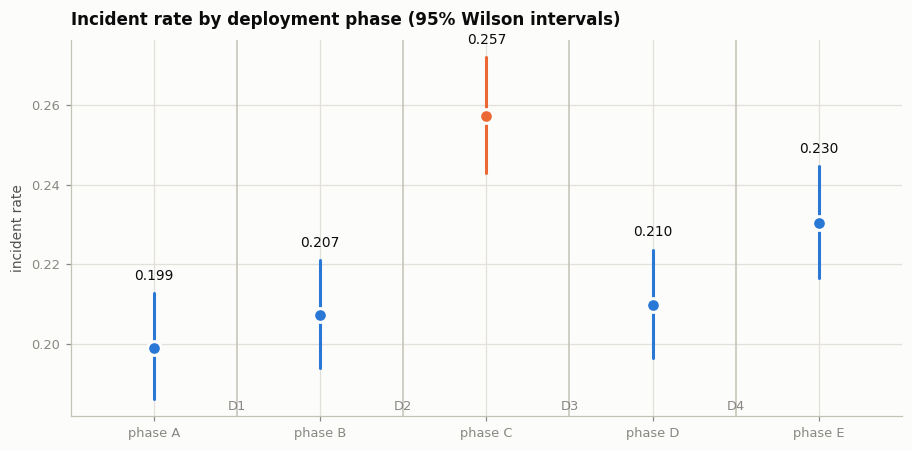

In [9]:
# ---- Task 2.4 ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.4, 4.2))
xs = np.arange(len(phase_stats))
for i, row in phase_stats.iterrows():
    colour = C["orange"] if row.phase == "C" else C["blue"]
    ax.plot([i, i], [row.ci_low, row.ci_high], color=colour, linewidth=2,
            solid_capstyle="round")
    ax.plot([i], [row.rate], "o", color=colour, markersize=9,
            markeredgecolor=INK["surface"], markeredgewidth=2)
    ax.annotate(f"{row.rate:.3f}", (i, row.ci_high), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=9, color=INK["primary"])

for i in range(4):
    ax.axvline(i + 0.5, color=INK["axis"], linewidth=1)
    ax.annotate(f"D{i+1}", (i + 0.5, ax.get_ylim()[0]), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=8.5, color=INK["muted"])

ax.set_xticks(xs)
ax.set_xticklabels([f"phase {p}" for p in phase_stats.phase])
ax.set_xlim(-0.5, len(phase_stats) - 0.5)
finish(ax, "Incident rate by deployment phase (95% Wilson intervals)",
       ylabel="incident rate")
fig.tight_layout()
fig.savefig(FIG / "02_phase_rates.png", bbox_inches="tight", dpi=140)
plt.show()
# ---- /Task 2.4 --------------------------------------------------------------

## Part 3 — Baseline model, by hand

### Task 3.1 — Split by time, not at random

Split `dev` into train (first 75% of the period) and test (last 25%) **by
timestamp**.

Why not a random split? Because rows from the same hour on neighbouring
instances are nearly duplicates. A random split puts some of them in train and
some in test, so the test set is no longer independent and your score comes
out flattering. Splitting on time is how the model will actually be used:
fit on the past, predict the future.

In [10]:
# ---- Task 3.1 ---------------------------------------------------------------
split_at = dev.timestamp.quantile(0.75)
tr_mask = (dev.timestamp < split_at).to_numpy()
te_mask = (dev.timestamp >= split_at).to_numpy()

y_tr = dev[TARGET].to_numpy()[tr_mask]
y_te = dev[TARGET].to_numpy()[te_mask]

print(f"split at {split_at}")
print(f"  train {tr_mask.sum():,} rows   incident rate {y_tr.mean():.4f}")
print(f"  test  {te_mask.sum():,} rows   incident rate {y_te.mean():.4f}")

# ---- /Task 3.1 --------------------------------------------------------------

check("train comes strictly before test",
      dev.timestamp[tr_mask].max() < dev.timestamp[te_mask].min())
check("split is roughly 75/25", abs(tr_mask.mean() - 0.75) < 0.02,
      f"train fraction = {tr_mask.mean():.3f}")

split at 2026-02-18 22:30:00
  train 12,960 rows   incident rate 0.2181
  test  4,320 rows   incident rate 0.2285
  [PASS] train comes strictly before test
  [PASS] split is roughly 75/25   train fraction = 0.750


True

### Task 3.2 — Least squares by hand

Fit a linear regression on the **10 raw numeric columns** using the normal
equation, implemented in NumPy.

We are minimising the squared error over $w \in \mathbb{R}^d$, $b \in
\mathbb{R}$:

$$L(w, b) = \sum_{i=1}^{n}\left(x_i^\top w + b - y_i\right)^2
          = \lVert Xw + b\mathbf{1} - y \rVert_2^2$$

The clean way to handle the intercept is to fold it into the matrix. Append a
column of ones,

$$\tilde X = \begin{bmatrix} \mathbf{1} & X \end{bmatrix}
             \in \mathbb{R}^{n \times (d+1)}, \qquad
  \beta = \begin{bmatrix} b \\ w \end{bmatrix} \in \mathbb{R}^{d+1}$$

so that $L(\beta) = \lVert \tilde X\beta - y\rVert^2$. Setting
$\nabla_\beta L = 2\tilde X^\top(\tilde X\beta - y) = 0$ gives the **normal
equations** $\tilde X^\top \tilde X \beta = \tilde X^\top y$, hence

$$\boxed{\;\hat\beta = (\tilde X^\top \tilde X)^{-1}\tilde X^\top y\;}
  \qquad \hat b = \hat\beta_0,\quad \hat w = \hat\beta_{1:d}$$

**Solve, do not invert.** `np.linalg.solve(A, c)` computes $A^{-1}c$ without
ever forming $A^{-1}$: it is roughly 2× faster and numerically better
conditioned. `np.linalg.inv(A) @ c` is the classic beginner's line and is
wrong for both reasons.

(Yes, we are fitting a regression to a 0/1 target. That is a *linear
probability model*: the scores are not calibrated probabilities and can fall
outside [0, 1], but AUC only cares about the **ranking**, so it is fine here.)

In [11]:
# ---- Task 3.2 ---------------------------------------------------------------
def fit_ols(X, y):
    """Least squares with an intercept. Returns (weights, intercept)."""
    X1 = np.hstack([np.ones((X.shape[0], 1)), X])
    beta = np.linalg.solve(X1.T @ X1, X1.T @ y)
    return beta[1:], beta[0]


X_raw = dev[NUMERIC].to_numpy(float)
w_raw, b_raw = fit_ols(X_raw[tr_mask], y_tr)

print(f"{'feature':22s}{'weight':>14}")
for name, wi in zip(NUMERIC, w_raw):
    print(f"{name:22s}{wi:14.6f}")
print(f"{'intercept':22s}{b_raw:14.6f}")

from sklearn.linear_model import LinearRegression

sk = LinearRegression().fit(X_raw[tr_mask], y_tr)
# ---- /Task 3.2 --------------------------------------------------------------

check("weights match sklearn", np.allclose(w_raw, sk.coef_, atol=1e-8))
check("intercept matches sklearn", np.isclose(b_raw, sk.intercept_, atol=1e-8))

feature                       weight
cpu_util                    0.253056
mem_util                    0.284493
p99_latency_ms              0.000047
request_rate                0.000084
error_rate_pct              0.138364
queue_depth                 0.014491
cache_hit_ratio            -0.594778
gc_pause_ms                 0.000287
active_connections          0.000053
disk_io_wait_ms             0.016631
intercept                   0.057928


  [PASS] weights match sklearn
  [PASS] intercept matches sklearn


True

### Task 3.3 — AUC by hand

Implement AUC yourself. Use the rank identity rather than integrating a curve
— it is three lines and it is exactly what AUC *means*:

> AUC is the probability that a randomly chosen positive scores above a
> randomly chosen negative.

Formally, with $\psi$ counting a tie as half a win,

$$\psi(a, b) = \mathbb{1}[a > b] + \tfrac{1}{2}\,\mathbb{1}[a = b]$$

the definition is an average over **all** positive–negative pairs:

$$\mathrm{AUC} = \frac{1}{n_+ n_-}
  \sum_{i:\,y_i=1}\;\sum_{j:\,y_j=0} \psi(s_i, s_j)$$

Computing that double sum directly costs $O(n_+ n_-)$ — about 4 million
operations here. The **Mann–Whitney identity** collapses it to a single sort.
Let $r_i$ be the rank of $s_i$ in the *pooled* sample (ranks $1 \dots n$) and
$R_+ = \sum_{i:\,y_i=1} r_i$. Then

$$\boxed{\;\mathrm{AUC}
  = \frac{R_+ - \dfrac{n_+(n_++1)}{2}}{n_+ n_-}\;}$$

The intuition for the correction term: if the positives took the top $n_+$
ranks they would sum to $n_- n_+ + \frac{n_+(n_++1)}{2}$, so subtracting
$\frac{n_+(n_++1)}{2}$ removes the ranks positives contribute *among
themselves*, leaving only wins over negatives.

Ties must get **average** ranks, which is precisely why $\psi$ scores them
$\tfrac12$ — the two conventions agree. `scipy.stats.rankdata` averages ties
by default; using an ordinal rank instead is the classic bug here.

Check against `sklearn.metrics.roc_auc_score`.

In [12]:
# ---- Task 3.3 ---------------------------------------------------------------
def auc_score(y_true, score):
    """AUC via the Mann-Whitney rank identity."""
    y_true = np.asarray(y_true)
    ranks = stats.rankdata(score)          # average ranks for ties
    n_pos = int(y_true.sum())
    n_neg = y_true.size - n_pos
    return (ranks[y_true == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


from sklearn.metrics import roc_auc_score

scores_te = X_raw[te_mask] @ w_raw + b_raw
AUC_BASELINE = auc_score(y_te, scores_te)

print(f"baseline test AUC (ours)    : {AUC_BASELINE:.6f}")
print(f"baseline test AUC (sklearn) : {roc_auc_score(y_te, scores_te):.6f}")

# ---- /Task 3.3 --------------------------------------------------------------

check("AUC matches sklearn",
      np.isclose(AUC_BASELINE, roc_auc_score(y_te, scores_te), atol=1e-12))
check("AUC is in a sensible range for this task", 0.75 < AUC_BASELINE < 0.85,
      f"AUC = {AUC_BASELINE:.4f}")

baseline test AUC (ours)    : 0.808049
baseline test AUC (sklearn) : 0.808049
  [PASS] AUC matches sklearn
  [PASS] AUC is in a sensible range for this task   AUC = 0.8080


True

### Task 3.4 — Sanity baselines

A number needs something to be compared against. Report the AUC of:

1. random scores,
2. the single best individual feature,

and confirm your model beats both.

In [13]:
# ---- Task 3.4 ---------------------------------------------------------------
random_auc = auc_score(y_te, rng.normal(size=y_te.size))

single = pd.Series({name: auc_score(y_te, X_raw[te_mask, j])
                    for j, name in enumerate(NUMERIC)})
# A feature that predicts "downward" is just as useful flipped, so rank on the
# distance from 0.5.
best_feature = (single - 0.5).abs().idxmax()

print(f"random scores           : {random_auc:.4f}")
print(f"best single feature     : {single[best_feature]:.4f}   ({best_feature})")
print(f"our 10-feature model    : {AUC_BASELINE:.4f}")
print("\nAUC of each feature alone:")
print(single.sort_values(key=lambda s: (s - 0.5).abs(), ascending=False).to_string())

# ---- /Task 3.4 --------------------------------------------------------------

check("beats random", AUC_BASELINE > 0.65)
check("beats the best single feature",
      AUC_BASELINE > max(single[best_feature], 1 - single[best_feature]))

random scores           : 0.5124
best single feature     : 0.7046   (p99_latency_ms)
our 10-feature model    : 0.8080

AUC of each feature alone:
p99_latency_ms        0.704607
cpu_util              0.679330
queue_depth           0.677705
request_rate          0.672601
error_rate_pct        0.659917
mem_util              0.616953
gc_pause_ms           0.605977
cache_hit_ratio       0.415340
active_connections    0.568590
disk_io_wait_ms       0.562050
  [PASS] beats random
  [PASS] beats the best single feature


True

## Part 4 — Make it better

Baseline is about **0.81**. Your target is **0.87 or better** on the same test
split, using the same model class (linear regression). Everything you gain has
to come from the *features*.

Work through 4.1–4.4, then report your best in 4.5.

### Task 4.1 — Standardisation: a checkpoint

Standardise every feature to mean 0 / std 1, refit, and recompute the AUC:

$$\tilde x_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}, \qquad
  \mu_j = \frac{1}{n}\sum_{i=1}^{n} x_{ij}, \qquad
  \sigma_j = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_{ij}-\mu_j)^2}$$

Compute $\mu_j, \sigma_j$ on the **training rows only** and apply those same
numbers to the test rows — that is why the function takes `mean` and `std` as
optional arguments. Guard $\sigma_j = 0$ (a constant column) by substituting
1, or you divide by zero.

**Before you run it, write down what you expect.** Then look at the answer.

To predict it, ask: in matrix form standardising is
$\tilde X = (X - \mathbf{1}\mu^\top)S^{-1}$ with
$S = \mathrm{diag}(\sigma_1,\dots,\sigma_d)$, which is invertible. So is the
set of functions

$$\left\{\,x \mapsto \tilde x^\top \tilde w + \tilde b \;:\;
  \tilde w \in \mathbb{R}^d,\ \tilde b \in \mathbb{R}\right\}$$

the same set as $\{x \mapsto x^\top w + b\}$, or a different one? And if it is
the same set, what can least squares possibly do differently?

In [14]:
# ---- Task 4.1 ---------------------------------------------------------------
def standardize(X, mean=None, std=None):
    """Standardise columns. Pass mean/std to reuse training statistics."""
    if mean is None:
        mean = X.mean(axis=0)
    if std is None:
        std = X.std(axis=0)
    return (X - mean) / np.where(std == 0, 1.0, std), mean, std


Xs_tr, mu, sd = standardize(X_raw[tr_mask])
Xs_te, _, _ = standardize(X_raw[te_mask], mu, sd)

w_s, b_s = fit_ols(Xs_tr, y_tr)
auc_standardised = auc_score(y_te, Xs_te @ w_s + b_s)

print(f"AUC raw          : {AUC_BASELINE:.10f}")
print(f"AUC standardised : {auc_standardised:.10f}")
print(f"difference       : {auc_standardised - AUC_BASELINE:.2e}")

# ---- /Task 4.1 --------------------------------------------------------------

check("standardisation changed the AUC by nothing at all",
      np.isclose(auc_standardised, AUC_BASELINE, atol=1e-9))

AUC raw          : 0.8080488900
AUC standardised : 0.8080488900
difference       : 0.00e+00
  [PASS] standardisation changed the AUC by nothing at all


True

**Why it is exactly zero.**

Standardising is an *affine, invertible* change of variables. If
$\tilde X = (X - \mu)/\sigma$ then any linear function of $\tilde X$ is also a
linear function of $X$:

$$\tilde X \tilde w + \tilde b
  = X\left(\tfrac{\tilde w}{\sigma}\right)
    + \left(\tilde b - \tfrac{\mu^\top \tilde w}{\sigma}\right)$$

So the two problems have the *same* set of reachable predictions, and least
squares finds the best one in that set either way. The fitted values are
identical to floating-point noise — so every metric is too, AUC included.

**Then why does everyone standardise?** Because it matters for things that are
*not* plain OLS:

* **gradient descent** — the usable learning rate is set by the largest
  feature scale, so without standardising, small-scale features barely move
  (this is the §4 result from lesson 1);
* **regularisation** — ridge/lasso penalise $\|w\|$, and that penalty is not
  scale-invariant, so unstandardised features get penalised unequally;
* **distance-based models** — kNN, SVM, k-means are meaningless without it;
* **reading coefficients** — standardised weights are comparable to each other.

It is good practice. It is not a way to raise AUC on an OLS fit, and any
tutorial implying otherwise is wrong.

### Task 4.2 — Transform the skewed features

*This* changes the predictions, because $\log$ is **not** an affine map:
there is no pair $(a, b)$ with $\log x = ax + b$, so the set of reachable
functions genuinely grows.

Apply

$$x \mapsto \log x \quad\text{or}\quad
  x \mapsto \log(1+x) \;\;(\texttt{np.log1p})$$

to the heavy-tailed columns, refit, and report the gain.

Use `log1p` wherever a column can be exactly $0$, since $\log 0 = -\infty$.
`error_rate_pct` is exactly zero for many windows; `disk_io_wait_ms` gets
arbitrarily close, so shift it by a small constant first. Check
`(df[col] == 0).any()` rather than guessing which columns need it.

Why a log at all: these columns are roughly log-normal, so $\log x$ is roughly
symmetric. A squared-error fit is dominated by the largest residuals, and on a
raw heavy-tailed column a handful of extreme rows drag the whole hyperplane
toward themselves.

In [15]:
# ---- Task 4.2 ---------------------------------------------------------------
def build_numeric(frame):
    """Numeric block with the skewed columns log-transformed."""
    out = pd.DataFrame(index=frame.index)
    out["cpu_util"] = frame.cpu_util
    out["mem_util"] = frame.mem_util
    out["log_p99_latency"] = np.log(frame.p99_latency_ms)
    out["log_request_rate"] = np.log(frame.request_rate)
    out["log1p_error_rate"] = np.log1p(frame.error_rate_pct)     # exact zeros
    out["queue_depth"] = frame.queue_depth.astype(float)
    out["cache_hit_ratio"] = frame.cache_hit_ratio
    out["log_gc_pause"] = np.log(frame.gc_pause_ms)
    out["log_active_connections"] = np.log(frame.active_connections)
    out["log_disk_io_wait"] = np.log(frame.disk_io_wait_ms + 0.05)  # near-zeros
    return out


X_log = build_numeric(dev).to_numpy(float)
w_l, b_l = fit_ols(X_log[tr_mask], y_tr)
auc_logs = auc_score(y_te, X_log[te_mask] @ w_l + b_l)

print(f"baseline        : {AUC_BASELINE:.4f}")
print(f"+ log transforms: {auc_logs:.4f}   ({auc_logs - AUC_BASELINE:+.4f})")

# ---- /Task 4.2 --------------------------------------------------------------

check("log transforms helped", auc_logs > AUC_BASELINE)

baseline        : 0.8080
+ log transforms: 0.8263   (+0.0183)
  [PASS] log transforms helped


True

### Task 4.3 — Use the categorical columns

So far you have thrown away `region`, `instance_type` and `service_tier`
entirely. A linear model cannot consume strings, so encode them.

A categorical column with levels $\{c_1, \dots, c_K\}$ becomes $K$ indicator
columns:

$$D_{ik} = \mathbb{1}\!\left[\text{category}_i = c_k\right],
  \qquad k = 1, \dots, K$$

Implement it by hand — `np.unique(..., return_inverse=True)` gives an integer
code per row, and then row $k$ of `np.eye(K)` *is* the one-hot vector for
category $k$, so `np.eye(K)[codes]` encodes the whole column at once.

**Drop one level per column.** Every row belongs to exactly one category, so

$$\sum_{k=1}^{K} D_{ik} = 1 \quad \text{for every } i
  \qquad\Longleftrightarrow\qquad D\mathbf{1}_K = \mathbf{1}_n$$

which is *exactly* the intercept column. So $[\mathbf{1}, D]$ has rank $K$,
not $K+1$, making $\tilde X^\top \tilde X$ **singular** and
`np.linalg.solve` raise `LinAlgError`. Dropping one level (the "reference"
or "baseline") fixes it, and every remaining coefficient is then read as
*"effect relative to the dropped level"*.

Then refit and report the gain.

In [16]:
# ---- Task 4.3 ---------------------------------------------------------------
def one_hot(labels, categories=None, drop_first=True):
    """One-hot encode string labels. Returns (matrix, column_names).

    `categories` lets you force the same columns on another frame -- essential
    when encoding a test set that may not contain every level.
    """
    if categories is None:
        categories = np.unique(labels)
    codes = np.searchsorted(categories, labels)
    mat = np.eye(len(categories))[codes]
    names = list(categories)
    if drop_first:
        mat, names = mat[:, 1:], names[1:]
    return mat, names


def encode_categoricals(frame, cats=None):
    """One-hot every categorical column, keeping a stable column order."""
    blocks, names, out_cats = [], [], {}
    for col in CATEGORICAL:
        levels = None if cats is None else cats[col]
        mat, nm = one_hot(frame[col].to_numpy(), levels)
        out_cats[col] = np.unique(frame[col].to_numpy()) if cats is None else levels
        blocks.append(mat)
        names += [f"{col}={v}" for v in nm]
    return np.hstack(blocks), names, out_cats


cat_matrix, cat_names, CATS = encode_categoricals(dev)
X_cat = np.hstack([X_log, cat_matrix])

w_c, b_c = fit_ols(X_cat[tr_mask], y_tr)
auc_cats = auc_score(y_te, X_cat[te_mask] @ w_c + b_c)

print(f"encoded {len(cat_names)} dummy columns: {cat_names}")
print(f"\n+ log transforms : {auc_logs:.4f}")
print(f"+ one-hot        : {auc_cats:.4f}   ({auc_cats - auc_logs:+.4f})")

# Every dummy weight is relative to the level that was DROPPED, so print those
# baselines too -- otherwise the signs below are unreadable.
print("\nbaseline (dropped) level per column:")
for col in CATEGORICAL:
    print(f"  {col:16s} baseline = {sorted(dev[col].unique())[0]}")

print("\nlearned categorical effects (relative to the baseline level above):")
for name, wi in sorted(zip(cat_names, w_c[X_log.shape[1]:]), key=lambda t: -t[1]):
    print(f"  {name:34s}{wi:+.4f}")

# ---- /Task 4.3 --------------------------------------------------------------

check("one-hot encoding helped", auc_cats > auc_logs)
check("dummies are 0/1 only", set(np.unique(cat_matrix)) <= {0.0, 1.0})

encoded 7 dummy columns: ['region=eu-central-1', 'region=us-east-1', 'region=us-west-2', 'instance_type=m5.large', 'instance_type=r5.2xlarge', 'service_tier=free', 'service_tier=pro']

+ log transforms : 0.8263
+ one-hot        : 0.8642   (+0.0379)

baseline (dropped) level per column:
  region           baseline = ap-south-1
  instance_type    baseline = c5.xlarge
  service_tier     baseline = enterprise

learned categorical effects (relative to the baseline level above):
  instance_type=m5.large            +0.0438
  instance_type=r5.2xlarge          -0.0510
  region=eu-central-1               -0.1083
  service_tier=pro                  -0.1284
  region=us-east-1                  -0.1286
  region=us-west-2                  -0.1296
  service_tier=free                 -0.1911
  [PASS] one-hot encoding helped
  [PASS] dummies are 0/1 only


True

The learned effects are readable: `ap-south-1` carries a much higher incident
rate than the other regions, `enterprise` traffic breaches its (stricter) SLA
more often than `free`, and the memory-heavy `r5.2xlarge` instances fail
least. None of this was recoverable from the numeric columns — which is why
one-hot encoding is the single biggest win available here.

### Task 4.4 — Interactions

A linear model can only add effects up: it predicts $\sum_j w_j x_j$, so the
contribution of feature $j$ never depends on feature $k$. If "high CPU is
fine, and a deep queue is fine, but high CPU **while** the queue is deep means
trouble", no pair of weights can express that.

The fix is to enlarge the feature map. Replace $x$ with

$$\phi(x) = \bigl(\underbrace{x_1, \dots, x_d}_{\text{main effects}},\;
  \underbrace{\{x_i x_j\}_{1 \le i \le j \le d}}_{\text{interactions and squares}}\bigr)$$

which has dimension

$$d + \binom{d+1}{2} = d + \frac{d(d+1)}{2}
  \;=\; 10 + 55 = 65 \text{ columns here}$$

The model stays **linear in its parameters** — so the normal equation still
applies unchanged — while becoming quadratic in the original features. Taking
$i \le j$ rather than $i < j$ keeps the squares $x_i^2$, which let the model
express "moderate is best" curvature that pure cross terms cannot.

`np.triu_indices(d)` gives exactly the $i \le j$ index pairs, and
`X[:, :, None] * X[:, None, :]` broadcasts to an $(n, d, d)$ array of all
products — index it with those pairs.

**Standardise the numeric block first.** Products of raw features vary
wildly in scale ($x_i x_j$ has units of $x_i$ times $x_j$), which wrecks the
conditioning of $\tilde X^\top \tilde X$. Keep the dummies as they are — they
are already $0/1$, and squaring a dummy just reproduces it
($D_{ik}^2 = D_{ik}$), which would add exact duplicate columns.

In [17]:
# ---- Task 4.4 ---------------------------------------------------------------
def add_interactions(X):
    """Append every product x_i * x_j with i <= j."""
    d = X.shape[1]
    i, j = np.triu_indices(d)
    outer = X[:, :, None] * X[:, None, :]
    return np.hstack([X, outer[:, i, j]]), list(zip(i, j))


Z_all, _, _ = standardize(X_log, *standardize(X_log[tr_mask])[1:])
Z_inter, pairs = add_interactions(Z_all)
X_full = np.hstack([Z_inter, cat_matrix])

w_f, b_f = fit_ols(X_full[tr_mask], y_tr)
auc_full = auc_score(y_te, X_full[te_mask] @ w_f + b_f)

print(f"{X_log.shape[1]} numeric -> {Z_inter.shape[1]} with interactions "
      f"(+{len(pairs)}), plus {len(cat_names)} dummies = {X_full.shape[1]} columns")
print(f"\n+ one-hot      : {auc_cats:.4f}")
print(f"+ interactions : {auc_full:.4f}   ({auc_full - auc_cats:+.4f})")

# ---- /Task 4.4 --------------------------------------------------------------

check("interactions helped", auc_full > auc_cats)

10 numeric -> 65 with interactions (+55), plus 7 dummies = 72 columns

+ one-hot      : 0.8642
+ interactions : 0.8808   (+0.0166)
  [PASS] interactions helped


True

### Task 4.5 — The same thing with an sklearn Pipeline

Everything above, expressed as a `Pipeline` + `ColumnTransformer`.

This is not just tidier. A pipeline **cannot leak**: `fit` learns the scaler
means and the encoder categories from training data only, and `transform`
reapplies them. The hand-rolled version above is correct only because we were
careful to pass training statistics around by hand every single time — and
that is exactly the kind of care that fails silently in a real project.

In [18]:
# ---- Task 4.5 ---------------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer, OneHotEncoder,
                                   PolynomialFeatures, StandardScaler)

LOG_COLS = ["p99_latency_ms", "request_rate", "error_rate_pct", "gc_pause_ms",
            "active_connections", "disk_io_wait_ms"]
PLAIN_COLS = ["cpu_util", "mem_util", "queue_depth", "cache_hit_ratio"]

numeric_pipe = Pipeline([
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scale", StandardScaler()),
])
plain_pipe = Pipeline([("scale", StandardScaler())])

pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("logged", numeric_pipe, LOG_COLS),
        ("plain", plain_pipe, PLAIN_COLS),
        ("cats", OneHotEncoder(drop="first", handle_unknown="ignore",
                               sparse_output=False), CATEGORICAL),
    ])),
    ("interactions", PolynomialFeatures(degree=2, interaction_only=False,
                                        include_bias=False)),
    ("model", LinearRegression()),
])

train_df, test_df = dev[tr_mask], dev[te_mask]
pipe.fit(train_df, y_tr)
auc_pipeline = auc_score(y_te, pipe.predict(test_df))

print(f"sklearn pipeline AUC : {auc_pipeline:.4f}")
print(f"hand-built AUC       : {auc_full:.4f}")
print(f"\nfeatures after preprocessing: "
      f"{pipe.named_steps['prep'].transform(train_df).shape[1]}")
print(f"after PolynomialFeatures    : "
      f"{pipe.named_steps['interactions'].n_output_features_}")

# ---- /Task 4.5 --------------------------------------------------------------

check("pipeline is in the same league as the hand-built model",
      abs(auc_pipeline - auc_full) < 0.05,
      f"difference {auc_pipeline - auc_full:+.4f}")

sklearn pipeline AUC : 0.8798
hand-built AUC       : 0.8808

features after preprocessing: 17
after PolynomialFeatures    : 170
  [PASS] pipeline is in the same league as the hand-built model   difference -0.0010


True

The two differ slightly because they are not quite the same model — the
pipeline logs a different subset of columns and expands interactions across
the dummies too. That is fine; the point is that the pipeline expresses the
whole preprocessing story as one fitted object you can hand to
`cross_val_score` or save to disk without it silently forgetting a scaler.

### Task 4.6 — One more idea, and a trap

Task 1.4 showed a clear daily cycle in the incident rate. That looks like a
free feature: add hour-of-day and let the model use it.

Try it — add hour-of-day (as `sin`/`cos`, and as dummies) on top of your best
model — and report what happens **before** reading the explanation below.

In [19]:
# ---- Task 4.6 ---------------------------------------------------------------
hours = dev.timestamp.dt.hour.to_numpy()
cyclical = np.column_stack([np.sin(2 * np.pi * hours / 24),
                            np.cos(2 * np.pi * hours / 24)])
hour_dummies = one_hot(hours.astype(str))[0]

X_cyc = np.hstack([X_full, cyclical])
X_hod = np.hstack([X_full, hour_dummies])

w_cy, b_cy = fit_ols(X_cyc[tr_mask], y_tr)
w_hd, b_hd = fit_ols(X_hod[tr_mask], y_tr)
auc_cyc = auc_score(y_te, X_cyc[te_mask] @ w_cy + b_cy)
auc_hod = auc_score(y_te, X_hod[te_mask] @ w_hd + b_hd)

# Is the hour informative on its own? Check the marginal rate spread first.
by_hour = dev.groupby(dev.timestamp.dt.hour)[TARGET].mean()
print(f"incident rate by hour ranges {by_hour.min():.3f} - {by_hour.max():.3f} "
      f"(spread {by_hour.max() - by_hour.min():.3f}) -- clearly not flat\n")
print(f"best model so far      : {auc_full:.4f}")
print(f"+ sin/cos of hour      : {auc_cyc:.4f}   ({auc_cyc - auc_full:+.4f})")
print(f"+ hour-of-day dummies  : {auc_hod:.4f}   ({auc_hod - auc_full:+.4f})")

ladder = pd.DataFrame([
    ("raw numeric features", AUC_BASELINE),
    ("+ standardisation", auc_standardised),
    ("+ log transforms", auc_logs),
    ("+ one-hot categoricals", auc_cats),
    ("+ interactions", auc_full),
    ("sklearn pipeline", auc_pipeline),
], columns=["model", "test AUC"])
ladder["gain vs baseline"] = ladder["test AUC"] - AUC_BASELINE
print(ladder.to_string(index=False, formatters={
    "test AUC": "{:.4f}".format, "gain vs baseline": "{:+.4f}".format}))

BEST_AUC = auc_full
print(f"\nbest: {BEST_AUC:.4f}   (target was 0.87)")
check("hit the 0.87 target", BEST_AUC >= 0.87, f"AUC = {BEST_AUC:.4f}")

incident rate by hour ranges 0.153 - 0.296 (spread 0.143) -- clearly not flat

best model so far      : 0.8808
+ sin/cos of hour      : 0.8806   (-0.0002)
+ hour-of-day dummies  : 0.8804   (-0.0004)
                 model test AUC gain vs baseline
  raw numeric features   0.8080          +0.0000
     + standardisation   0.8080          +0.0000
      + log transforms   0.8263          +0.0183
+ one-hot categoricals   0.8642          +0.0561
        + interactions   0.8808          +0.0728
      sklearn pipeline   0.8798          +0.0717

best: 0.8808   (target was 0.87)
  [PASS] hit the 0.87 target   AUC = 0.8808


True

**Hour of day adds nothing — and that is the lesson.**

The incident rate genuinely does vary by hour, so hour-of-day *is* correlated
with the target. But the reason it varies is that the fleet is busier in the
afternoon — and we already measure `request_rate`, `active_connections` and
`cpu_util` directly. The hour is a **proxy** for load, and we have the real
thing.

> A feature is useful only if it adds information **conditional on the
> features you already have.** Marginal correlation with the target is not
> enough, and is what makes naive "top-k correlated features" selection go
> wrong.

Adding the dummies is in fact very slightly *worse*, which is the expected
behaviour of 23 extra parameters that carry no new signal: they fit noise in
the training period and cost you a little on the test period.

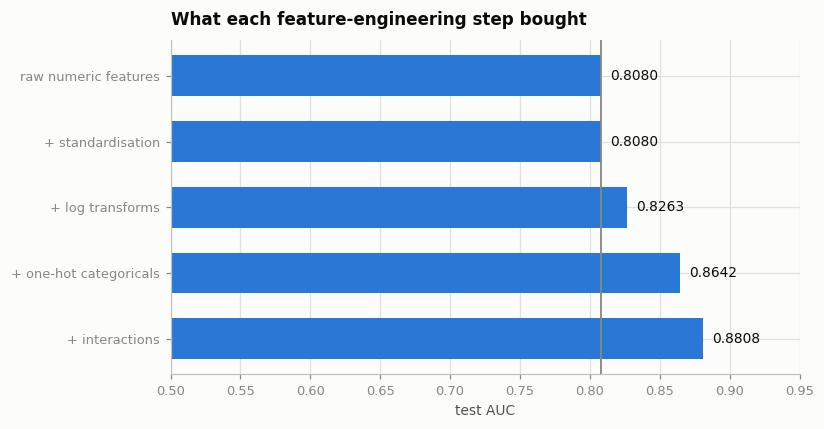

In [20]:
fig, ax = plt.subplots(figsize=(7.6, 4.0))
steps = ladder[ladder.model != "sklearn pipeline"]
ax.barh(range(len(steps)), steps["test AUC"], color=C["blue"], height=0.62)
ax.set_yticks(range(len(steps)))
ax.set_yticklabels(steps.model)
ax.invert_yaxis()
ax.set_xlim(0.5, 0.95)
ax.axvline(AUC_BASELINE, color=INK["muted"], linewidth=1.2)
for i, v in enumerate(steps["test AUC"]):
    ax.annotate(f"{v:.4f}", (v, i), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK["primary"])
finish(ax, "What each feature-engineering step bought", xlabel="test AUC")
fig.tight_layout()
fig.savefig(FIG / "03_auc_ladder.png", bbox_inches="tight", dpi=140)
plt.show()
# ---- /Task 4.6 --------------------------------------------------------------

## Part 5 — The logs nobody looked at

Now open the horizon: 60 days of logs that played no part in anything above.

Your model was validated on data from the same 60-day window it was trained
on. The real question — the only one that matters in production — is whether
it still works months later.

### Task 5.1 — Does it still work?

Score the horizon with the model from Task 4.4 and compute AUC in a **rolling
window** over time (14 days wide, stepped every 3 days). Plot it.

For a window starting at time $t$ with width $\Delta$, the index set is

$$W_t = \{\,i \;:\; t \le \tau_i < t + \Delta\,\}$$

where $\tau_i$ is row $i$'s timestamp, and you report
$\mathrm{AUC}\left(y_{W_t},\, s_{W_t}\right)$ plotted at the window's centre
$t + \Delta/2$. Step $t$ forward by 3 days and repeat.

Two details worth getting right:

* a window with **only one class** has undefined AUC ($n_+ n_- = 0$), so skip
  it rather than dividing by zero;
* the windows **overlap** (14-day width, 3-day step), so neighbouring points
  share most of their data and the curve is smoother than independent
  estimates would be. That is the point — it trades independence for
  readability — but it means you should not read a single wobble as a signal.

Implement the rolling evaluation yourself.

In [21]:
# ---- Task 5.1 ---------------------------------------------------------------
def build_design(frame, mu, sd, cats):
    """Reproduce the Task 4.4 design matrix for any frame."""
    num = build_numeric(frame).to_numpy(float)
    z, _, _ = standardize(num, mu, sd)
    z_inter, _ = add_interactions(z)
    cat_mat, _, _ = encode_categoricals(frame, cats)
    return np.hstack([z_inter, cat_mat])


_, mu_log, sd_log = standardize(X_log[tr_mask])


def rolling_auc(timestamps, y_true, scores, window_days=14, step_days=3):
    """AUC in a sliding time window. Returns (centres, aucs, counts)."""
    t = pd.to_datetime(pd.Series(timestamps)).to_numpy()
    y_true, scores = np.asarray(y_true), np.asarray(scores)
    start, end = t.min(), t.max()
    width = np.timedelta64(window_days, "D")
    step = np.timedelta64(step_days, "D")

    centres, aucs, counts = [], [], []
    left = start
    while left + width <= end:
        m = (t >= left) & (t < left + width)
        if m.sum() > 50 and 0 < y_true[m].sum() < m.sum():
            centres.append(left + width / 2)
            aucs.append(auc_score(y_true[m], scores[m]))
            counts.append(int(m.sum()))
        left = left + step
    return np.array(centres), np.array(aucs), np.array(counts)


X_hor = build_design(horizon, mu_log, sd_log, CATS)
y_hor = horizon[TARGET].to_numpy()
hor_scores = X_hor @ w_f + b_f

centres, aucs, counts = rolling_auc(horizon.timestamp, y_hor, hor_scores)

print(f"AUC on the dev test split : {auc_full:.4f}")
print(f"AUC over the whole horizon: {auc_score(y_hor, hor_scores):.4f}")
print(f"\nrolling windows: {len(aucs)}   first {aucs[0]:.4f}   last {aucs[-1]:.4f}")
print(f"decay from first to last  : {aucs[-1] - aucs[0]:+.4f}")

# ---- /Task 5.1 --------------------------------------------------------------

check("quality decayed over the horizon", aucs[-3:].mean() < aucs[:3].mean(),
      f"{aucs[:3].mean():.4f} -> {aucs[-3:].mean():.4f}")

AUC on the dev test split : 0.8808
AUC over the whole horizon: 0.8669

rolling windows: 16   first 0.8813   last 0.8514
decay from first to last  : -0.0299
  [PASS] quality decayed over the horizon   0.8811 -> 0.8533


True

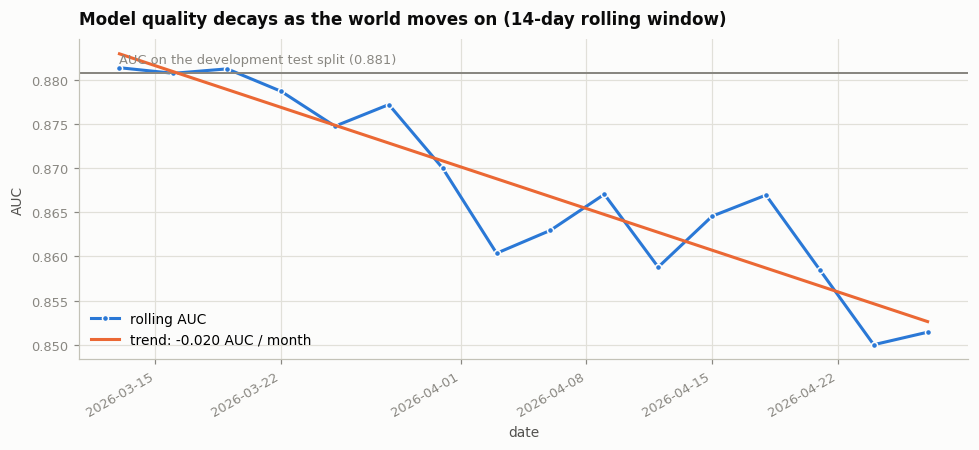

In [22]:
# ---- Task 5.1b --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.plot(centres, aucs, "o-", color=C["blue"], markersize=4,
        markeredgecolor=INK["surface"], markeredgewidth=1, label="rolling AUC")
ax.axhline(auc_full, color=INK["muted"], linewidth=1.3)
ax.annotate(f"AUC on the development test split ({auc_full:.3f})",
            xy=(centres[0], auc_full), xytext=(0, 6), textcoords="offset points",
            fontsize=8.5, color=INK["muted"])
# least-squares trend through the rolling points
xnum = (centres - centres[0]) / np.timedelta64(1, "D")
slope, intercept = np.polyfit(xnum, aucs, 1)
ax.plot(centres, intercept + slope * xnum, color=C["orange"],
        label=f"trend: {slope * 30:+.3f} AUC / month")
finish(ax, "Model quality decays as the world moves on (14-day rolling window)",
       xlabel="date", ylabel="AUC", legend=True)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIG / "04_decay.png", bbox_inches="tight", dpi=140)
plt.show()
# ---- /Task 5.1b -------------------------------------------------------------

### Task 5.2 — Diagnose it

Quality dropped. There are two different reasons that can happen, and they
call for different responses:

Write $P_{\text{old}}$ for the joint distribution during development and
$P_{\text{new}}$ for the one at the end of the horizon. Since
$P(x, y) = P(x)\,P(y \mid x)$, exactly one of the two factors can move:

* **Covariate shift** — the inputs moved, the rule did not:

  $$P_{\text{new}}(x) \ne P_{\text{old}}(x), \qquad
    P_{\text{new}}(y \mid x) = P_{\text{old}}(y \mid x)$$

  The model is still *right*; it is just being asked about regions of feature
  space it saw rarely. Often survivable, and fixable by reweighting.

* **Concept drift** — the rule itself changed:

  $$P_{\text{new}}(y \mid x) \ne P_{\text{old}}(y \mid x)$$

  What the model learned is no longer true. **Only retraining fixes this.**

Test for both:

1. **Covariate shift.** Compare feature means in `dev` against the last 21
   days, in units of the dev standard deviation so the columns are
   comparable:

   $$\delta_j = \frac{\bar x_j^{\,\text{new}} - \bar x_j^{\,\text{old}}}
                     {\sigma_j^{\,\text{old}}}$$

   Treat $|\delta_j| \gtrsim 0.3$ as worth noticing.

2. **Concept drift.** Refit on the last 21 days and compare coefficients:

   $$\Delta_j = \hat w_j^{\,\text{new}} - \hat w_j^{\,\text{old}}$$

   A large $|\Delta_j|$ is suspicious; a **sign flip**,
   $\mathrm{sign}(\hat w_j^{\,\text{new}}) \ne
    \mathrm{sign}(\hat w_j^{\,\text{old}})$, is conclusive — the model is now
   pushing that feature in the wrong direction.

In [23]:
# ---- Task 5.2 ---------------------------------------------------------------
late = horizon[horizon.timestamp >= horizon.timestamp.max() - pd.Timedelta(days=21)]

dev_num = build_numeric(dev)
late_num = build_numeric(late)
shift = pd.DataFrame({
    "dev_mean": dev_num.mean(),
    "late_mean": late_num.mean(),
    "shift_in_sd": (late_num.mean() - dev_num.mean()) / dev_num.std(),
})
print("COVARIATE SHIFT — feature means, in dev standard deviations")
print(shift.reindex(shift.shift_in_sd.abs().sort_values(ascending=False).index)
      .to_string(formatters={"dev_mean": "{:.3f}".format,
                             "late_mean": "{:.3f}".format,
                             "shift_in_sd": "{:+.2f}".format}))

X_late = build_design(late, mu_log, sd_log, CATS)
w_late, b_late = fit_ols(X_late, late[TARGET].to_numpy())

n_num = X_log.shape[1]
coef = pd.DataFrame({
    "dev": w_f[:n_num],
    "late": w_late[:n_num],
}, index=build_numeric(dev).columns)
coef["change"] = coef.late - coef.dev
coef["flipped_sign"] = np.sign(coef.dev) != np.sign(coef.late)

print("\nCONCEPT DRIFT — main-effect coefficients, dev vs last 21 days")
print(coef.reindex(coef.change.abs().sort_values(ascending=False).index)
      .to_string(formatters={"dev": "{:+.4f}".format, "late": "{:+.4f}".format,
                             "change": "{:+.4f}".format}))

print(f"\ncoefficients that changed sign: "
      f"{list(coef.index[coef.flipped_sign])}")
# ---- /Task 5.2 --------------------------------------------------------------

check("found at least one sign flip (concept drift)", coef.flipped_sign.any())

COVARIATE SHIFT — feature means, in dev standard deviations
                       dev_mean late_mean shift_in_sd
log_active_connections    6.247     6.401       +0.35
log_request_rate          6.802     6.969       +0.32
log_p99_latency           4.928     5.341       +0.30
log_gc_pause              3.215     3.118       -0.08
log_disk_io_wait          0.209     0.179       -0.03
mem_util                  0.583     0.587       +0.03
cpu_util                  0.556     0.558       +0.02
queue_depth               9.305     9.346       +0.01
log1p_error_rate          0.320     0.319       -0.00
cache_hit_ratio           0.886     0.886       -0.00

CONCEPT DRIFT — main-effect coefficients, dev vs last 21 days
                           dev    late  change  flipped_sign
log_gc_pause           +0.0347 +0.1280 +0.0934         False
cache_hit_ratio        -0.0475 +0.0038 +0.0512          True
log1p_error_rate       +0.0661 +0.0365 -0.0297         False
log_request_rate       +0.0306 +0.0105 

True

**Diagnosis.** Both are present, but they are not equally important.

There *is* covariate shift — traffic and latency have crept up, so
`log_request_rate`, `log_active_connections` and `log_p99_latency` all sit
noticeably higher than in the development period. On its own that would be
survivable.

The real problem is **concept drift**: `cache_hit_ratio` has changed sign. In
the development period a high cache-hit ratio meant *fewer* incidents; by the
end of the horizon it means *more*. A model carrying the old coefficient is
now actively penalising the wrong windows. `log1p_error_rate` has also lost
most of its weight, and `log_gc_pause` has gained a lot.

That is not something better features fix. The relationship changed, so the
model has to be refit.

### Task 5.3 — Retrain

Simulate what an on-call team would actually do: hold out the **last 21 days**
as a fresh test set, and compare

* the original dev-trained model, versus
* the same model retrained on the **21 days immediately before** that.

Note how little data the retrained model gets — and that it wins anyway.

In [24]:
# ---- Task 5.3 ---------------------------------------------------------------
cut = horizon.timestamp.max() - pd.Timedelta(days=21)
recent = horizon[(horizon.timestamp >= cut - pd.Timedelta(days=21))
                 & (horizon.timestamp < cut)]
final = horizon[horizon.timestamp >= cut]

X_recent = build_design(recent, mu_log, sd_log, CATS)
X_final = build_design(final, mu_log, sd_log, CATS)
y_final = final[TARGET].to_numpy()

w_re, b_re = fit_ols(X_recent, recent[TARGET].to_numpy())

auc_stale = auc_score(y_final, X_final @ w_f + b_f)
auc_fresh = auc_score(y_final, X_final @ w_re + b_re)

print(f"evaluation window : last 21 days, {len(final):,} rows")
print(f"retraining data   : previous 21 days, {len(recent):,} rows "
      f"({len(recent) / len(dev):.0%} of the original training set)\n")
print(f"  dev-trained model (stale) : AUC {auc_stale:.4f}")
print(f"  retrained on recent data  : AUC {auc_fresh:.4f}")
print(f"  recovered                 : {auc_fresh - auc_stale:+.4f}")

# ---- /Task 5.3 --------------------------------------------------------------

check("retraining improved the model", auc_fresh > auc_stale)

evaluation window : last 21 days, 6,072 rows
retraining data   : previous 21 days, 6,048 rows (35% of the original training set)

  dev-trained model (stale) : AUC 0.8543
  retrained on recent data  : AUC 0.8887
  recovered                 : +0.0344
  [PASS] retraining improved the model


True

### Task 5.4 — How much history should you keep?

Retraining on 21 days worked. Would 60 days work better — more data — or
worse, because older data describes a world that no longer exists?

This is a bias–variance trade-off in an unusual variable, the **window
length** $L$. Training on $\{i : \text{cut} - L \le \tau_i < \text{cut}\}$:

* larger $L$ $\Rightarrow$ more rows $\Rightarrow$ **lower variance** in
  $\hat w$ (roughly $\propto 1/\sqrt{n}$, and $n$ grows linearly with $L$);
* larger $L$ $\Rightarrow$ older rows, drawn from a
  $P(y \mid x)$ further from today's $\Rightarrow$ **higher bias**.

The optimum $L^{\ast}$ is wherever those two curves cross, and it depends on how
fast the concept is drifting — there is no universal answer, which is why you
sweep it.

Sweep the training-window length and find out.

In [25]:
# ---- Task 5.4 ---------------------------------------------------------------
rows = []
for days in [7, 14, 21, 30, 45, 60, 90]:
    win_start = cut - pd.Timedelta(days=days)
    win = clean[(clean.timestamp >= win_start) & (clean.timestamp < cut)].copy()
    win[NUMERIC] = win[NUMERIC].fillna(impute_values)
    if len(win) < 500:
        continue
    Xw = build_design(win, mu_log, sd_log, CATS)
    ww, bw = fit_ols(Xw, win[TARGET].to_numpy())
    rows.append({"window_days": days, "n_rows": len(win),
                 "auc": auc_score(y_final, X_final @ ww + bw)})
sweep = pd.DataFrame(rows)
sweep["vs_stale"] = sweep.auc - auc_stale
print(sweep.to_string(index=False, formatters={"auc": "{:.4f}".format,
                                               "vs_stale": "{:+.4f}".format}))
best = sweep.loc[sweep.auc.idxmax()]
print(f"\nbest window: {int(best.window_days)} days  (AUC {best.auc:.4f})")
print(f"stale dev-trained model:      AUC {auc_stale:.4f}")

 window_days  n_rows    auc vs_stale
           7    2016 0.8872  +0.0329
          14    4032 0.8893  +0.0350
          21    6048 0.8887  +0.0344
          30    8640 0.8850  +0.0307
          45   12960 0.8806  +0.0263
          60   17280 0.8759  +0.0216
          90   25920 0.8697  +0.0153

best window: 14 days  (AUC 0.8893)
stale dev-trained model:      AUC 0.8543


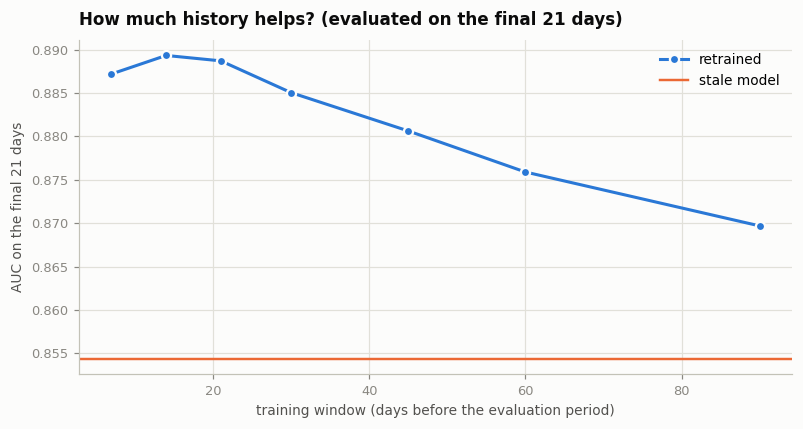

In [26]:
fig, ax = plt.subplots(figsize=(7.4, 4.0))
ax.plot(sweep.window_days, sweep.auc, "o-", color=C["blue"],
        markeredgecolor=INK["surface"], markeredgewidth=1.5, label="retrained")
ax.axhline(auc_stale, color=C["orange"], linewidth=1.6, label="stale model")
finish(ax, "How much history helps? (evaluated on the final 21 days)",
       xlabel="training window (days before the evaluation period)",
       ylabel="AUC on the final 21 days", legend=True)
fig.tight_layout()
fig.savefig(FIG / "05_window_sweep.png", bbox_inches="tight", dpi=140)
plt.show()
# ---- /Task 5.4 --------------------------------------------------------------